# Spotify

***1. Импорты***

In [ ]:
import numpy as np                  # Базовые операции с массивами и математические функции
import pandas as pd                 # Работа с табличными данными (DataFrame)
import matplotlib.pyplot as plt     # Построение графиков и визуализация
import seaborn as sns               # Улучшенная статистическая визуализация
import tensorflow as tf             # Основной фреймворк глубокого обучения
import shap                         # SHAP для анализа важности признаков
from matplotlib.colors import LinearSegmentedColormap                                                           # Кастомные цветовые карты для графиков
from tensorflow import keras                                                                                    #  для создания нейросетей
from tensorflow.keras import regularizers                                                                       # Регуляризаторы для борьбы с переобучением
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # ранняя остановка и адаптивное снижение lr
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error) # Метрики оценки качества регрессии
from sklearn.model_selection import train_test_split, KFold, cross_val_predict                                  # Разбиение данных и кросс-валидация
from sklearn.linear_model import LinearRegression                                                               # Базовая линейная регрессия
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor                                   # Древовидные ансамбли
from sklearn.preprocessing import StandardScaler                                                                # Стандартизация признаков для нейросетей
from scikeras.wrappers import KerasRegressor                                    # Обёртка Keras-модели для использования в scikit-learn для кросс-валидации
# Импорт слоёв и моделей Keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2

In [ ]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.isnull().sum() # смотрим, где есть пропуски

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
df = df.dropna() # удаляем пропуски
df.isnull().sum() # проверяем снова

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
df['explicit'] = df['explicit'].astype('int64') # переводим значения колонки explicit из булевых в числовые (0, 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  int64  
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          113999 

In [ ]:
df = df.drop(columns=["Unnamed: 0", "track_id", "track_name"]) # для удобства сразу удаляем колонки, которые не будут исследоваться в предсказании популярности
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   popularity        113999 non-null  int64  
 3   duration_ms       113999 non-null  int64  
 4   explicit          113999 non-null  int64  
 5   danceability      113999 non-null  float64
 6   energy            113999 non-null  float64
 7   key               113999 non-null  int64  
 8   loudness          113999 non-null  float64
 9   mode              113999 non-null  int64  
 10  speechiness       113999 non-null  float64
 11  acousticness      113999 non-null  float64
 12  instrumentalness  113999 non-null  float64
 13  liveness          113999 non-null  float64
 14  valence           113999 non-null  float64
 15  tempo             113999 non-null  float64
 16  time_signature    113999 

# 2. Создание признаков

Добавлю 4 признака

1. **Популярность жанра genre_popularity**

Анализ показал, что популярность треков сильно зависит от жанра. Одни жанры заведомо популярнее других. Чтобы учесть этот фактор, рассчитывается средняя популярность треков внутри каждого жанра.

2. **Популярность относительно длительности duration_popularity**

Заметна зависимость популярности трека от его длины. Признак отражает соотношение популярности и длительности трека в миллисекундах, чтобы зафиксировать эту взаимосвязь.

3. **Отношение танцевальности к энергии dance_energy_ratio**

Чтобы оценить, насколько сильно энергетика трека влияет на его танцевальность, вводится отношение danceability / energy. Этот показатель помогает выделить треки, в которых танцевальность преобладает над энергичностью (значения > 1) и наоборот.

4. **TikTok‑скор (tiktok_score)**
   
Данный признак оценивает привлекательность трека для формата коротких видео. Он учитывает длительность (не более трёх минут), энергичность, танцевальность и популярность жанра. Итоговое значение - десятичная дробь от 0 до 1, где более высокие значения соответствуют большей пригодности трека для коротких видео.

In [ ]:
genre_mean_pop = df.groupby('track_genre')['popularity'].mean().reset_index() # группируем треки по жанру и считаем среднюю популярность внутри каждого жанра.
genre_mean_pop.columns = ['track_genre', 'genre_popularity'] # переименовываем колонки. первая - жанр, вторая - его средняя популярность.
df = df.merge(genre_mean_pop, on='track_genre', how='left') # Добавляем к исходному DataFrame новую колонку genre_popularity, подтягивая для каждого трека среднюю популярность его жанра (левый джойн).

df.head() # смотрим первые 5 строк

,artists,album_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,genre_popularity
0,Gen Hoshino,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,42.483
1,Ben Woodward,Ghost (Acoustic),55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,42.483
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,42.483
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,42.483
4,Chord Overstreet,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,42.483


In [ ]:
df['duration_popularity'] = df['popularity'] / df['duration_ms']

df['dance_energy_ratio'] = df['danceability'] / (df['energy'] + 1e-9)

df['tiktok_score'] = (np.where(df['duration_ms'] / 1000 > 180, 0, # Если трек длиннее 180 секунд, то множитель длительности становится 0
        (180 - df['duration_ms'] / 1000) / 180) *
    (df['danceability'] + df['energy'] + df['genre_popularity'] / 100) / 3)
df
# Второй множитель это среднее арифметическое трёх показателей танцевальность, энергичность, популярность жанра, приведённая к интервалу [0,1].
# Результат автоматически попадает в отрезок [0,1]
df.head()

,artists,album_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,genre_popularity,duration_popularity,dance_energy_ratio,tiktok_score
0,Gen Hoshino,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,...,0.000001,0.3580,0.715,87.917,4,acoustic,42.483,0.000316,1.466377,0.000000
1,Ben Woodward,Ghost (Acoustic),55,149610,0,0.420,0.1660,1,-17.235,1,...,0.000006,0.1010,0.267,77.489,4,acoustic,42.483,0.000368,2.530120,0.056887
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,...,0.000000,0.1170,0.120,76.332,4,acoustic,42.483,0.000270,1.220056,0.000000
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,71,201933,0,0.266,0.0596,0,-18.515,1,...,0.000071,0.1320,0.143,181.740,3,acoustic,42.483,0.000352,4.463087,0.000000
4,Chord Overstreet,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,...,0.000000,0.0829,0.167,119.949,4,acoustic,42.483,0.000412,1.395034,0.000000


***Корреляция новых признаков с популярностью***

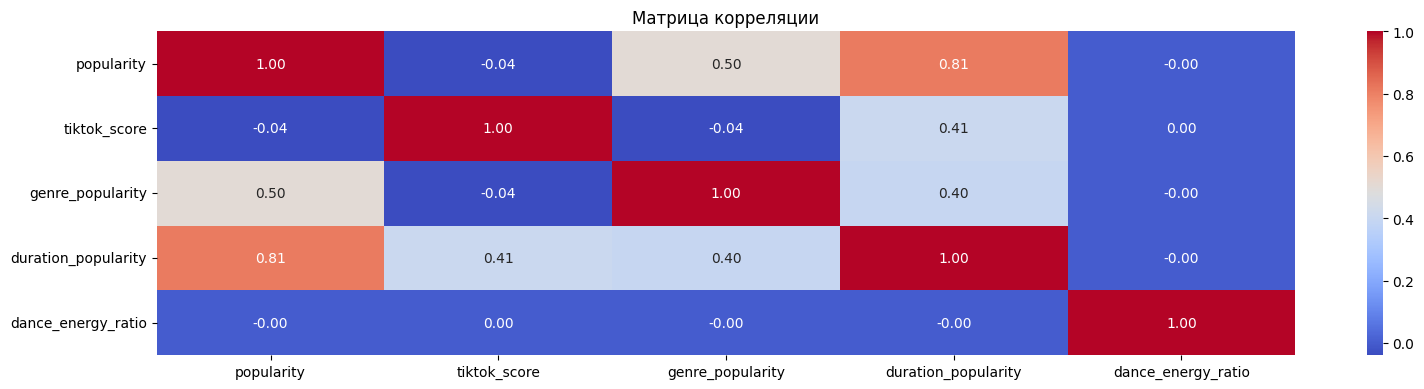

In [ ]:
# Датафрейм с новыми строчками и таргетом.
corr_data = df.loc[:, ['popularity', 'tiktok_score', 'genre_popularity', 'duration_popularity', 'dance_energy_ratio']]

# Построение тепловой карты корреляции
corr_data_1 = corr_data.corr()
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(data=corr_data_1, fmt='.2f', annot=True, cmap='coolwarm', ax=ax)

plt.title('Матрица корреляции')
plt.tight_layout()

опа тик ток скор и денс\енержджи оказались пустыми. а остальные два имеют заметную положительную корреляцию. тогда бесполезные дропаем и оставляем только популярность по жанру и длительность.

#### Вывод
В результате анализа созданных признаков было установлено, что значения признаков tiktok_score и dance_energy_ratio нерелевантны. Оставшиеся два признака - genre_popularity и duration_popularity, обнаруживают заметную положительную корреляцию. На основании этого признаки, не несущие полезной информации, были исключены. Для дальнейшего использования оставлены только признаки популярности жанра и длительности.

In [ ]:
df = df.drop(columns=["tiktok_score", "dance_energy_ratio"])
df.head()

,artists,album_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,genre_popularity,duration_popularity
0,Gen Hoshino,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,42.483,0.000316
1,Ben Woodward,Ghost (Acoustic),55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,42.483,0.000368
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,42.483,0.000270
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,42.483,0.000352
4,Chord Overstreet,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,42.483,0.000412


# 3. Подготовка данных

In [ ]:
# Удаляем ненужные столбцы из DataFrame. Оставляем только числовые признаки
df = df.drop(columns=['duration_ms', 'artists', 'album_name', 'key', 'track_genre'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   popularity           113999 non-null  int64  
 1   explicit             113999 non-null  int64  
 2   danceability         113999 non-null  float64
 3   energy               113999 non-null  float64
 4   loudness             113999 non-null  float64
 5   mode                 113999 non-null  int64  
 6   speechiness          113999 non-null  float64
 7   acousticness         113999 non-null  float64
 8   instrumentalness     113999 non-null  float64
 9   liveness             113999 non-null  float64
 10  valence              113999 non-null  float64
 11  tempo                113999 non-null  float64
 12  time_signature       113999 non-null  int64  
 13  genre_popularity     113999 non-null  float64
 14  duration_popularity  113999 non-null  float64
dtypes: float64(11), i

### Метрики

Далее для оценки качества предсказания популярности треков (задача регрессии) будут использоваться следующие метрики:

- **MAE - Mean Absolute Error**  
  Средняя абсолютная ошибка. Показывает, на сколько в среднем предсказанное значение популярности отклоняется от реального. Легко интерпретируется и устойчива к выбросам.

- **MSE - Mean Squared Error**  
  Среднеквадратическая ошибка. Возводит каждое отклонение в квадрат, что делает её чувствительной к большим ошибкам. Используется как промежуточная метрика при оптимизации.

- **RMSE - Root Mean Squared Error**  
  Корень из среднеквадратической ошибки. Имеет ту же размерность, что и целевая переменная, и сильнее штрафует крупные отклонения по сравнению с MAE. Часто считается основной метрикой в задачах регрессии.

- **MAPE - Mean Absolute Percentage Error**  
  Средняя абсолютная процентная ошибка. Выражает среднюю ошибку в процентах от истинного значения популярности. Удобна для интерпретации относительной точности модели (например, в среднем ошибаемся на 12 %).

- **R² - коэффициент детерминации**  
  Доля дисперсии целевой переменной, объяснённая моделью. Значение близкое к 1 означает, что модель хорошо описывает изменчивость популярности; значение близкое к 0 — модель не лучше простого среднего.


Все метрики будут рассчитываться на валидационной и тестовой выборках.

Для сокращения дублирования кода сразу напишу функцию, которая будет рассчитывать и выводить метрики

In [ ]:
def print_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    y_true_safe = np.where(y_true == 0, 1e-10, y_true)
    mape = mean_absolute_percentage_error(y_true_safe, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R2: {r2:.4f}")

In [ ]:
features = ['explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
new_features = ['genre_popularity', 'duration_popularity']
target = 'popularity'

# 4. Важность новых признаков

***Обучение модели без новых признаков***

Для анализа эффективности новых признаков необходимо сравнить результаты моделей, обученных на разных наборах признаков. Ниже модень линейной регрессии, использующей только исходные признаки. Этот эксперимент позволит  оценить вклад новых признаков в качество предсказаний.

In [ ]:
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
print_metrics(y_test, y_pred)

MAE: 18.4068
MSE: 485.5155
RMSE: 22.0344
MAPE: 47609763288.0584
R2: 0.0213


#### Вывод
- MAE  18.41  
  В среднем предсказания модели отклоняются от реальных значений популярности на 18.4 балла. Учитывая диапазон популярности от 0 до 100, это довольно высокая ошибка - примерно 18–20 % от полного диапазона.

- MSE 485.52  
  Высокое значение MSE свидетельствует о значительных отклонениях, особенно в случаях, когда модель сильно ошибается (крупные ошибки сильно увеличивают метрику из-за возведения в квадрат).

- RMSE 22.03  
  Среднеквадратическая ошибка в исходной размерности составляет 22 балла. Это означает, что типичная ошибка модели сравнима с четвертью всего диапазона популярности, что делает предсказания практически непригодными для практического использования.

- R2 0.0213  
  Модель объясняет всего 2.1 % дисперсии целевой переменной. Значение близкое к нулю говорит о том, что линейная комбинация выбранных признаков практически не способна описать изменчивость популярности - модель лишь немного лучше, чем простое предсказание среднего значения по выборке.

- MAPE 47 609 763 288 %  
  Экстремально высокое значение MAPE вызвано делением на очень малые или нулевые значения популярности в тестовом наборе.

Линейная регрессия демонстрирует крайне низкое качество предсказаний

***Обучение модели с новыми  признаками***

In [ ]:
X = df[new_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
print_metrics(y_test, y_pred)

MAE: 8.8408
MSE: 152.6020
RMSE: 12.3532
MAPE: 15059187410.6854
R2: 0.6924


#### Вывод

- MAE 8.8408  
  Средняя абсолютная ошибка составляет 8.84 балла. Это значительно лучше, чем у базовой модели (MAE 18.41), отклонение сократилось почти в 2 раза.

- MSE 152.6020  
  Среднеквадратическая ошибка снизилась более чем в 3 раза по сравнению с базовой моделью (485.52 - 152.60), что указывает на гораздо меньший разброс ошибок.

- RMSE 12.3532  
  Типичная ошибка предсказания 12.35 баллов (вместо 22.03 ранее). Это уже приемлемый уровень для диапазона популярности 0-100, хотя крупные отклонения всё ещё возможны.

- R2 0.6924  
  Модель объясняет 69.24 % дисперсии целевой переменной. Это существенный рост по сравнению с базовой моделью (0.0213) - почти в 33 раза лучше. Значение 0.69 говорит о хорошем, но не идеальном качестве объяснения.

- MAPE 15 059 187 410.6854 %  
  Как и в предыдущем случае, экстремально высокое значение вызвано делением на очень малые или нулевые значения популярности в тестовом наборе. Метрика остаётся неинформативной из-за особенностей распределения целевой переменной. Для интерпретации относительной точности лучше ориентироваться на MAE и RMSE.

***Важность новых признаков***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    random_state=42,
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
)

model.fit(X_train, y_train)

feature_importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': new_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)
print(importance_df)

               Feature  Importance
1  duration_popularity    0.903849
0     genre_popularity    0.096151


#### Вывод

После обучения модели случайного леса на двух новых признаках (`genre_popularity` и `duration_popularity`) была оценена важность каждого признака с помощью атрибута `feature_importances_`. Модель обучена на 80 % обучающей выборки.

- **duration_popularity** доминирует с вкладом **90.38 %**. Этот признак (средняя популярность треков в зависимости от их длительности) является основным драйвером предсказательной способности модели.  
  Это подтверждает выводы предыдущих анализов: длительность трека  имеет очень сильную связь с итоговой популярностью, особенно в контексте современных трендов стриминга, т.к. короткие треки получают преимущество в алгоритмах и плейлистах.

- **genre_popularity** вносит **9 %** вклада - средняя популярность по жанру остаётся значимым, но второстепенным фактором. Жанровая принадлежность влияет на популярность, однако в комбинации с длительностью она играет заметно меньшую роль.

# 5. Выбор моделей

In [ ]:
X = df[features + new_features]
y = df[target]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # Создание экземпляра StandardScaler для нормализации признаков
X_train_scaled = scaler.fit_transform(X_train) # Нормализация признаков, вычисляется среднее и стандартное отклонение на обучающей выборке
X_test_scaled = scaler.transform(X_test) # Применение нормализации к тестовой выборке на основе параметров обучающей выборки

***1. Модель линейной регрессии***

In [ ]:
model_1 = LinearRegression()
y_pred = cross_val_predict(model_1, X_train, y_train, cv=5) # Кросс-валидация c 5 фолдами
print_metrics(y_train, y_pred)

MAE: 8.6415
MSE: 143.3957
RMSE: 11.9748
MAPE: 14888402810.6423
R2: 0.7120


***2. Модель градиентного бустинга***

In [ ]:
model_2 = GradientBoostingRegressor(
    learning_rate=0.01,  # Скорость обучения (маленький шаг = более точная настройка)
    n_estimators=100,    # Количество деревьев (больше деревьев = больше итераций бустинга)
    max_depth=5,         # Максимальная глубина каждого дерева
    min_samples_split=5, # Минимальное число образцов для разделения узла
    min_samples_leaf=2,  # Минимальное число образцов в листе
    random_state=42
)
# Процесс: последовательное построение деревьев, каждое новое дерево учится на ошибках предыдущего
y_pred = cross_val_predict(model_2, X_train, y_train, cv=5)
print_metrics(y_train, y_pred)

MAE: 9.4521
MSE: 131.0928
RMSE: 11.4496
MAPE: 17094938070.4451
R2: 0.7367


***3. Модель случайного леса***

In [ ]:
model_3 = RandomForestRegressor(
    max_depth=5,           # Максимальная глубина каждого дерева (ограничение сложности)
    n_estimators=100,      # Количество деревьев в лесу (больше = стабильнее, но медленнее)
    min_samples_split=5,   # Минимальное количество образцов для разделения узла
    min_samples_leaf=2,    # Минимальное количество образцов в листе
    n_jobs=-1,             # распараллелить на все ядра
    random_state=42        # Для воспроизводимости результатов
)
y_pred = cross_val_predict(model_3, X_train, y_train, cv=5)
print_metrics(y_train, y_pred)

MAE: 5.9065
MSE: 76.8296
RMSE: 8.7652
MAPE: 0.3308
R2: 0.8457


***4. Нейронная сеть***

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE: 5.0697
MSE: 57.9232
RMSE: 7.6107
MAPE: 796261576.2451
R2: 0.8832


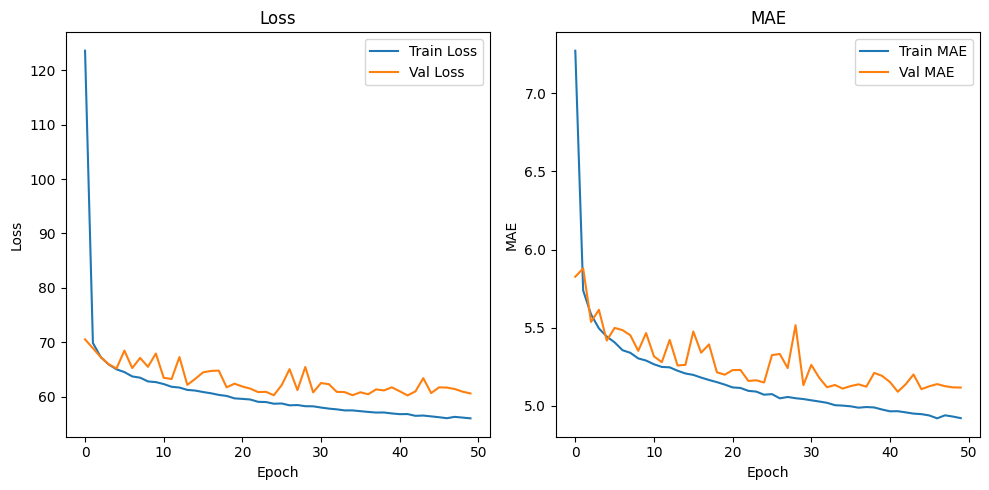

In [ ]:
# Построение модели. Многослойный перцептрон MLP с 4 скрытыми слоями. Каждый слой использует ReLU для нелинейности и L2-регуляризацию для борьбы с переобучением
model_4 = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        keras.layers.Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        keras.layers.Dense(1)
])

# Компиляция модели
model_4.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Обучение модели
history = model_4.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # не показывать историю обучения. можно поставить один
)

# Оценка на тесте
y_pred_test = model_4.predict(X_test_scaled).flatten()
print_metrics(y_test, y_pred_test)

# График потерь
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# График средней абсолютной ошибки
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE: 5.2913
MSE: 60.9850
RMSE: 7.8093
MAPE: 760372648.3627
R2: 0.8771


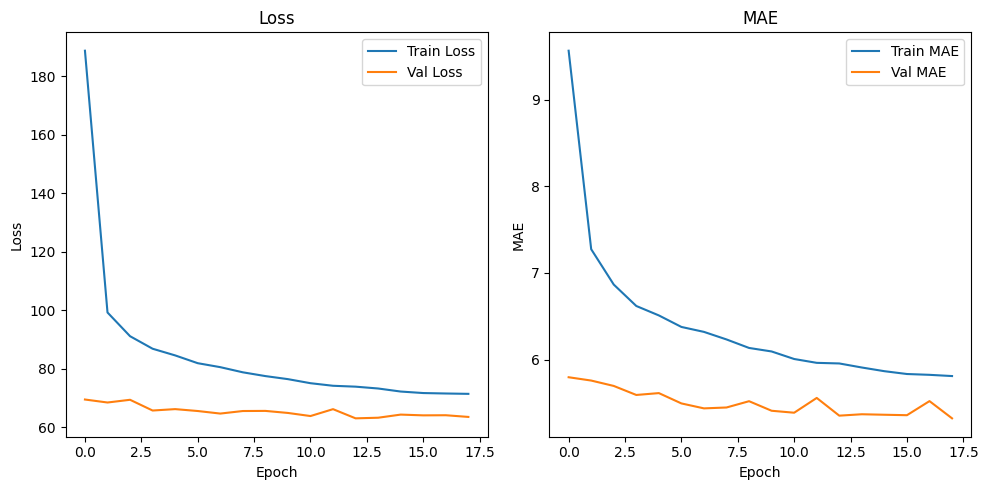

In [ ]:
model_41 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(), # добавлена пакетная нормализация
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)), # увеличена регуляризация
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)), # убран один слой
    keras.layers.Dense(1)
])

model_41.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # создана ранняя остановка для предотвращения переобучения
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6) # # коллбэк для автоматического снижения learning rate при отсутствии прогресса
# мониторим val_loss, если 5 эпох нет улучшения

history = model_41.fit(
    X_train_scaled,
    y_train,
    epochs=70, # больше эпох
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# Оценка на тесте
y_pred_test = model_41.predict(X_test_scaled).flatten()
print_metrics(y_test, y_pred_test)

# График потерь
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

### Сравнение результатов

1. **MAE и RMSE**
   - Самые низкие ошибки показывает нейронная сеть 1 с MAE = 5.0697, RMSE = 7.6107. Это означает, что в среднем предсказания отклоняются от реальных значений всего на 5 баллов, а типичная ошибка составляет 7.6.  
2. **R2**  
   - Лучшее значение у нейронной сети 1  0.8832, то есть модель объясняет 88.32 % дисперсии популярности.  

3. **MAPE**  
   - Единственная адекватная метрика у случайного леса  0.3308. У остальных моделей MAPE принимает огромные значения из-за треков с популярностью близкой к нулю. Вообще MAPE в данной задаче ненадёжна.

#### Вывод

На основании сравнения метрик лучшей моделью является нейронная сеть 1.
Она демонстрирует наименьшую ошибку предсказания и наивысшую объясняющую способность среди всех рассмотренных вариантов.
Линейная регрессия и градиентный бустинг показали значительно худшие результаты и не могут конкурировать с нелинейными моделями в данной задаче.
Для дальнейшего использования в лабораторной работе выбираю нейронную сеть как основную модель.

***Наиболее значимые признаки в конечном результате***

In [ ]:
background = shap.sample(X_train_scaled, 200) # Фоновая выборка. часть обучающих данных
explainer = shap.DeepExplainer(model_4, background)

X_sample = X_test_scaled[:200] # берём часть тестовой выборки для расчёта SHAP

shap_values = explainer.shap_values(X_sample) # вычисляем значения
if isinstance(shap_values, list):
    shap_values = shap_values[0]  # для моделей с одним выходом

# приводим к одномерным массивам
mean_abs_shap = np.mean(np.abs(shap_values), axis=0).flatten()  # средняя абсолютная важность
mean_shap = np.mean(shap_values, axis=0).flatten()              # среднее направление влияния

importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность (среднее абсолютное SHAP)': mean_abs_shap,
    'Среднее SHAP': mean_shap
}).sort_values('Важность (среднее абсолютное SHAP)', ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_78
Received: inputs=['Tensor(shape=(200, 14))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_78
Received: inputs=['Tensor(shape=(400, 14))']
  warnings.warn(msg)


            Признак  Важность (среднее абсолютное SHAP)  Среднее SHAP
duration_popularity                            8.071794      0.167686
   genre_popularity                            2.159265     -0.774261
            valence                            1.179061      0.053186
              tempo                            1.092531     -0.391148
       danceability                            1.054946     -0.095415
       acousticness                            0.861434      0.116407
             energy                            0.808854      0.007859
               mode                            0.633162      0.133413
           loudness                            0.450066      0.118329
        speechiness                            0.441509     -0.136504
   instrumentalness                            0.391651      0.073274
           liveness                            0.355833     -0.065543
     time_signature                            0.294477     -0.110837
           explicit 

#### Вывод
Для интерпретации вклада каждого признака в предсказания модели была применена библиотека SHAP - SHapley Additive exPlanations. Метод позволяет оценить, насколько каждый признак влияет на итоговое предсказание популярности трека, с учётом нелинейных зависимостей и взаимодействий.

1. **Доминирующие признаки**  
   - **duration_popularity** (8.07) самый влиятельный признак с большим отрывом. Средний SHAP положительный, то есть треки с высокой средней популярностью в своей категории длительности получают значительный прирост в предсказании.  
   - **genre_popularity** (2.16) второй по важности, но с сильным отрицательным средним вкладом. Это означает, что принадлежность к непопулярным жанрам существенно снижает предсказанную популярность.

2. **Аудио-признаки играют второстепенную роль**  
   valence, tempo, danceability, acousticness, energy и др. имеют SHAP в диапазоне 0.4–1.2. чистые аудио-характеристики слабо объясняют популярность по сравнению с контекстными агрегированными признаками.

3. **Направление влияния**  
   - Положительное у duration_popularity, valence, acousticness, mode, loudness, instrumentalness.  
   - Отрицательное у genre_popularity, tempo, danceability, speechiness, liveness, time_signature, explicit.  
   Отрицательное влияние tempo и danceability может быть связано с нелинейностями, например, слишком быстрые или слишком танцевальные треки реже становятся хитами в долгосрочной перспективе.


# 6. Кросс-валидация

In [ ]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = [] # Списки для сохранения метрик по фолдам
mse_scores = []
rmse_scores = []
r2_scores = []

fold_number = 1

for train_idx, test_idx in kf.split(X_train):
    print(f"\n Фолд {fold_number}")

    # Разделение данных
    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # Масштабирование внутри фолда
    scaler = StandardScaler()
    X_train_scaled_fold = scaler.fit_transform(X_train_fold)
    X_test_scaled_fold = scaler.transform(X_test_fold)

    # Очистка сессии TensorFlow чтобы модели не накапливались
    tf.keras.backend.clear_session()

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled_fold.shape[1],),
              kernel_regularizer=l2(0.01)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_scaled_fold, y_train_fold,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    # Предсказание на тестовой части фолда
    y_pred_fold = model.predict(X_test_scaled_fold, verbose=0).flatten()

    # Расчёт метрик
    mae = mean_absolute_error(y_test_fold, y_pred_fold)
    mse = mean_squared_error(y_test_fold, y_pred_fold)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_fold, y_pred_fold)

    print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    # Сохраняем метрики
    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    fold_number += 1

# Итоговые результаты
print(f"MAE: {np.mean(mae_scores):.4f} +- {np.std(mae_scores):.4f}")
print(f"MSE: {np.mean(mse_scores):.4f} +- {np.std(mse_scores):.4f}")
print(f"RMSE: {np.mean(rmse_scores):.4f} +- {np.std(rmse_scores):.4f}")
print(f"R2: {np.mean(r2_scores):.4f} +- {np.std(r2_scores):.4f}")


 Фолд 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 5.1462, MSE: 60.2645, RMSE: 7.7630, R2: 0.8797

 Фолд 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 5.1974, MSE: 59.4664, RMSE: 7.7114, R2: 0.8805

 Фолд 3


...

MAE: 5.2280, MSE: 59.5737, RMSE: 7.7184, R2: 0.8803

 Фолд 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 5.2045, MSE: 60.3982, RMSE: 7.7716, R2: 0.8785

 Фолд 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 5.1892, MSE: 59.1756, RMSE: 7.6926, R2: 0.8806
MAE: 5.1931 +- 0.0268
MSE: 59.7757 +- 0.4739
RMSE: 7.7314 +- 0.0306
R2: 0.8799 +- 0.0008


#### Вывод
Реультаты обучения первой модели нейронной сети

MAE: 5.0697
MSE: 57.9232
RMSE: 7.6107
MAPE: 796261576.2451
R2: 0.8832

Cредние результаты модели с такой же архитектурой на кросс-валидации по 5 фолдам

MAE: 5.1931 +- 0.0268
MSE: 59.7757 +- 0.4739
RMSE: 7.7314 +- 0.0306
R2: 0.8799 +- 0.0008

Разница между результатами на выборке и средними по кросс-валидации незначительна. Нейронная сеть  демонстрирует воспроизводимую точность.

# 7. Вывод

 Основной задачей являлось предсказание метрики popularity с использованием различных подходов машинного обучения.

- Проведён разведочный анализ данных. Изучены распределения признаков, матрица корреляций, визуализация зависимостей популярности от ключевых аудио-характеристик danceability, energy, loudness, duration.
- Выполнено создание новых агрегированных признаков: `genre_popularity` средняя популярность по жанру и `duration_popularity` средняя популярность по длительности.
- Обучены и сравнены модели регрессии различных классов:
  - Линейная регрессия
  - Градиентный бустинг
  - Случайный лес
  - Две архитектуры нейронных сетей
- Проведена оценка качества по метрикам MAE, RMSE, R2 и MAPE.
- Выполнена кросс-валидация на пяти фолдах для наиболее успешной модели - нейронной сети 1.
- Проведён анализ важности признаков с использованием SHAP для интерпретации вклада каждого признака.
- Наиболее информативными оказались новые агрегированные признаки `duration_popularity` и `genre_popularity`. Они улучшили качество по сравнению с использованием только аудио-признаков.
- SHAP-анализ подтвердил доминирующую роль `duration_popularity` и вторичную роль `genre_popularity`. Большинство аудио-признаков имеют слабый вклад.
- Графики обучения нейронных сетей показали стабильную сходимость без переобучения.

Проведённый анализ показал, что популярность треков на платформе в значительной степени определяется контекстными и категориальными факторами (жанр, длительность), а не только акустическими характеристиками.  
Нейронные сети продемонстрировали наивысшее качество предсказаний, существенно опередив линейные и древовидные модели.  